In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# # Stock Price Direction Prediction

Predicts next-day up/down direction for **Reliance** using technical 
indicators (RSI, MACD, Bollinger Bands) and Nifty 50 market-return features.
Models tested: Random Forest, Gradient Boosting, KNN, XGBoost.

Full write-up: see README.md

In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


FETCH DATA

In [3]:
import yfinance as yf

# Pick a ticker - e.g. Reliance on NSE, or AAPL for US stocks
ticker = "RELIANCE.NS"   # .NS suffix for NSE-listed stocks
data = yf.download(ticker, start="2021-01-01", end="2026-07-31")

print(data.head())
print(data.shape)

/tmp/ipykernel_16/1339324210.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-07-31")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-01-01  897.047119  901.334860  894.564705  897.272755    10015175
2021-01-04  898.559082  902.192359  888.245845  900.477287    24513534
2021-01-05  887.388306  895.286819  882.829682  888.697174    24123091
2021-01-06  863.986084  887.343111  859.878852  887.297984    46401468
2021-01-07  862.586975  877.864981  859.878925  866.807025    32325918
(1381, 5)


In [4]:
data['Close']

Ticker,RELIANCE.NS
Date,
2021-01-01,897.047119
2021-01-04,898.559082
2021-01-05,887.388306
2021-01-06,863.986084
2021-01-07,862.586975
...,...
2026-07-24,1278.000000
2026-07-27,1280.000000
2026-07-28,1267.699951


In [5]:
# Flatten MultiIndex columns from yfinance
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

In [6]:
data = data.reset_index()

In [7]:
data['target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

In [8]:
data

Price,Date,Close,High,Low,Open,Volume,target
0,2021-01-01,897.047119,901.334860,894.564705,897.272755,10015175,1
1,2021-01-04,898.559082,902.192359,888.245845,900.477287,24513534,0
2,2021-01-05,887.388306,895.286819,882.829682,888.697174,24123091,0
3,2021-01-06,863.986084,887.343111,859.878852,887.297984,46401468,0
4,2021-01-07,862.586975,877.864981,859.878925,866.807025,32325918,1
...,...,...,...,...,...,...,...
1376,2026-07-24,1278.000000,1283.400024,1249.800049,1265.000000,9817000,1
1377,2026-07-27,1280.000000,1288.699951,1278.000000,1288.199951,7163132,0
1378,2026-07-28,1267.699951,1279.199951,1265.900024,1275.000000,9312184,1
1379,2026-07-29,1275.900024,1282.400024,1268.699951,1275.000000,9448307,1


In [9]:
import yfinance as yf

nifty = yf.download('^NSEI', start="2021-01-01", end="2026-07-31")
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)
nifty = nifty.reset_index()

/tmp/ipykernel_16/1408096402.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download('^NSEI', start="2021-01-01", end="2026-07-31")
[*********************100%***********************]  1 of 1 completed


In [10]:
nifty['nifty_return_1d'] = nifty['Close'].pct_change(1)
nifty['nifty_return_5d'] = nifty['Close'].pct_change(5)

In [11]:
!pip install ta -q

  Preparing metadata (setup.py) ... done


In [12]:
import ta

# RSI
data['RSI'] = ta.momentum.RSIIndicator(close=data['Close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(close=data['Close'])
data['MACD'] = macd.macd()
data['MACD_signal'] = macd.macd_signal()
data['MACD_diff'] = macd.macd_diff()

# Bollinger Bands
bollinger = ta.volatility.BollingerBands(close=data['Close'], window=20)
data['BB_high'] = bollinger.bollinger_hband()
data['BB_low'] = bollinger.bollinger_lband()
data['BB_width'] = bollinger.bollinger_wband()

# Lagged returns
data['return_1d'] = data['Close'].pct_change(1)
data['return_5d'] = data['Close'].pct_change(5)

# Rolling volatility
data['volatility_5d'] = data['Close'].pct_change().rolling(5).std()
data['volatility_10d'] = data['Close'].pct_change().rolling(10).std()

In [13]:
data

Price,Date,Close,High,Low,Open,Volume,target,RSI,MACD,MACD_signal,MACD_diff,BB_high,BB_low,BB_width,return_1d,return_5d,volatility_5d,volatility_10d
0,2021-01-01,897.047119,901.334860,894.564705,897.272755,10015175,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-04,898.559082,902.192359,888.245845,900.477287,24513534,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001685,NaN,NaN,NaN
2,2021-01-05,887.388306,895.286819,882.829682,888.697174,24123091,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012432,NaN,NaN,NaN
3,2021-01-06,863.986084,887.343111,859.878852,887.297984,46401468,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.026372,NaN,NaN,NaN
4,2021-01-07,862.586975,877.864981,859.878925,866.807025,32325918,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001619,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1376,2026-07-24,1278.000000,1283.400024,1249.800049,1265.000000,9817000,1,42.358858,-6.516995,-4.849336,-1.667659,1328.737550,1269.102453,4.591129,0.004559,-0.037070,0.008065,0.011210
1377,2026-07-27,1280.000000,1288.699951,1278.000000,1288.199951,7163132,0,43.077589,-7.248276,-5.329124,-1.919152,1328.779615,1266.960388,4.763129,0.001565,-0.032575,0.008924,0.011048
1378,2026-07-28,1267.699951,1279.199951,1265.900024,1275.000000,9312184,1,39.791453,-8.719816,-6.007262,-2.712554,1330.137282,1262.982713,5.179442,-0.009609,-0.027614,0.008019,0.011358
1379,2026-07-29,1275.900024,1282.400024,1268.699951,1275.000000,9448307,1,42.917754,-9.119224,-6.629654,-2.489569,1329.252551,1260.657446,5.297103,0.006468,-0.009856,0.008666,0.011616


In [14]:
!pip install pandas-profiling

In [15]:
# from pandas_profiling import ProfileReport
# prof=ProfileReport(data)
# prof.to_file(output_file='ProfileReport.html')

Nice — this is a full ydata-profiling (pandas-profiling) report. Here's what it's telling you, in plain terms:

Dataset shape: 1381 rows, 18 columns, 0.7% missing cells (182 total), 0 duplicate rows, spanning 2021-01-01 to 2026-07-30.

Target balance (the important one):
target = 1 → 708 rows (51.3%), target = 0 → 673 rows (48.7%).

This confirms what we discussed earlier — it's nearly balanced. So your baseline to beat is ~51.3% accuracy (always guessing "up"). Accuracy is a fair metric here since classes aren't skewed. Good news, one less thing to worry about.

Missing values (expected, not a bug):
MACD ~25 missing (1.8%), MACD_signal/diff ~33 missing (2.4%), BB_high/low/width ~19 missing (1.4%). This is just the indicator warm-up period (RSI needs 14 days, Bollinger needs 20, MACD needs 26 to stabilize) — exactly what we talked about. dropna() handles this.

The 22 alerts — mostly "High correlation" warnings, and this is the one thing worth actually understanding:

BB_high, BB_low, Close, High, Low, Open are all highly correlated with each other — makes total sense, they're all just price levels moving together.
MACD and MACD_signal are highly correlated — expected, since signal line is just a smoothed version of MACD.
MACD_diff and RSI are correlated — both are momentum measures, so this tracks.
volatility_5d, volatility_10d, BB_width are correlated — all three measure "how choppy is the market," so naturally redundant.

What this means for modeling — this is a genuine decision point:
This is multicollinearity — several of your features carry overlapping information. It won't break XGBoost (tree models handle correlated features fine, unlike linear regression), but it does mean:

Don't use raw Close, High, Low, Open as features directly — you're already not using these for training (good), only the derived indicators.
You could drop one of each near-duplicate pair (e.g., keep BB_width, drop volatility_10d) to simplify, but it's optional, not required, for a tree-based model.
In your writeup, mentioning "I noted multicollinearity among momentum/volatility features but retained them since XGBoost is robust to it" is a solid, accurate line that shows you understood the report rather than just running it.

Bottom line: this EDA is done, it confirmed your assumptions (balanced target, expected NaN pattern, sensible feature redundancy), you don't need to dig further. Move straight to dropna → TimeSeriesSplit → XGBoost.

# handing misssing data
These aren't randomly missing values — they're structurally missing. RSI needs 14 prior days to compute, Bollinger needs 20, MACD needs 26. The first ~25 rows of your dataset literally cannot have these values because the math requires history that doesn't exist yet at the start of your dataset. This is fundamentally different from, say, a survey where someone skipped a question.
Imputing here would be fabricating information you don't have and can't have.

In [16]:
data

Price,Date,Close,High,Low,Open,Volume,target,RSI,MACD,MACD_signal,MACD_diff,BB_high,BB_low,BB_width,return_1d,return_5d,volatility_5d,volatility_10d
0,2021-01-01,897.047119,901.334860,894.564705,897.272755,10015175,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-04,898.559082,902.192359,888.245845,900.477287,24513534,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001685,NaN,NaN,NaN
2,2021-01-05,887.388306,895.286819,882.829682,888.697174,24123091,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012432,NaN,NaN,NaN
3,2021-01-06,863.986084,887.343111,859.878852,887.297984,46401468,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.026372,NaN,NaN,NaN
4,2021-01-07,862.586975,877.864981,859.878925,866.807025,32325918,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001619,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1376,2026-07-24,1278.000000,1283.400024,1249.800049,1265.000000,9817000,1,42.358858,-6.516995,-4.849336,-1.667659,1328.737550,1269.102453,4.591129,0.004559,-0.037070,0.008065,0.011210
1377,2026-07-27,1280.000000,1288.699951,1278.000000,1288.199951,7163132,0,43.077589,-7.248276,-5.329124,-1.919152,1328.779615,1266.960388,4.763129,0.001565,-0.032575,0.008924,0.011048
1378,2026-07-28,1267.699951,1279.199951,1265.900024,1275.000000,9312184,1,39.791453,-8.719816,-6.007262,-2.712554,1330.137282,1262.982713,5.179442,-0.009609,-0.027614,0.008019,0.011358
1379,2026-07-29,1275.900024,1282.400024,1268.699951,1275.000000,9448307,1,42.917754,-9.119224,-6.629654,-2.489569,1329.252551,1260.657446,5.297103,0.006468,-0.009856,0.008666,0.011616


In [17]:
data_clean = data.dropna().reset_index(drop=True)
print(f"Before: {data.shape}, After: {data_clean.shape}")

Before: (1381, 18), After: (1348, 18)


In [18]:
data_clean = data_clean.merge(
    nifty[['Date', 'nifty_return_1d', 'nifty_return_5d']],
    on='Date', how='left'
)
data_clean = data_clean.dropna()

In [19]:
print(data_clean.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'target', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff', 'BB_high', 'BB_low', 'BB_width', 'return_1d', 'return_5d', 'volatility_5d', 'volatility_10d', 'nifty_return_1d', 'nifty_return_5d']


In [20]:
# Make sure data is sorted by date (should already be, but just to be safe)
data_clean = data_clean.sort_values('Date').reset_index(drop=True)

# Define feature columns — exclude Date, raw price columns, and target itself
feature_cols = [
    'RSI', 'MACD', 'MACD_signal', 'MACD_diff',
    'BB_high', 'BB_low', 'BB_width',
    'return_1d', 'return_5d',
    'volatility_5d', 'volatility_10d'
]
feature_cols += ['nifty_return_1d', 'nifty_return_5d']
X = data_clean[feature_cols]
y = data_clean['target']

# Chronological split — last 20% of rows (by date) become test set
split_idx = int(len(data_clean) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows ({data_clean['Date'].iloc[0].date()} to {data_clean['Date'].iloc[split_idx-1].date()})")
print(f"Test:  {X_test.shape[0]} rows ({data_clean['Date'].iloc[split_idx].date()} to {data_clean['Date'].iloc[-1].date()})")

# Sanity check — class balance shouldn't be wildly different between train/test
print("\nTrain target balance:\n", y_train.value_counts(normalize=True))
print("\nTest target balance:\n", y_test.value_counts(normalize=True))

Train: 1075 rows (2021-02-18 to 2025-06-26)
Test:  269 rows (2025-06-27 to 2026-07-30)

Train target balance:
 target
1    0.523721
0    0.476279
Name: proportion, dtype: float64

Test target balance:
 target
0    0.527881
1    0.472119
Name: proportion, dtype: float64


In [21]:
# from sklearn.model_selection import TimeSeriesSplit

# tscv = TimeSeriesSplit(n_splits=5)
# for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
#     print(f"Fold {fold+1}: train size={len(train_idx)}, val size={len(val_idx)}")

In [22]:
print(X_train.describe())

Price          RSI         MACD  MACD_signal    MACD_diff      BB_high  \
count  1075.000000  1075.000000  1075.000000  1075.000000  1075.000000   
mean     51.994269     3.405935     3.359634     0.046301  1249.089482   
std      12.043681    17.860957    16.685546     5.662154   163.918241   
min      24.801442   -37.745277   -34.276960   -20.976870   906.524361   
25%      43.063067    -9.485708    -8.970904    -3.769180  1144.000612   
50%      51.936380     1.553653     1.102089     0.166470  1232.621747   
75%      61.299966    15.627233    14.636415     4.162418  1324.691548   
max      82.648053    47.056683    43.277316    18.305012  1631.080028   

Price       BB_low     BB_width    return_1d    return_5d  volatility_5d  \
count  1075.000000  1075.000000  1075.000000  1075.000000    1075.000000   
mean   1135.464847     9.619102     0.000530     0.002617       0.013012   
std     157.240966     3.955178     0.014575     0.032319       0.006608   
min     822.211249     2.5898

# why outlier removal not required
1. Your models don't get confused by outliers (mostly).
Tree-based models — Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM (7 of your 9 algorithms) — split data by asking "is this value above or below X?" at each node. An extreme value just becomes a data point on one side of a threshold; it doesn't distort the whole tree the way it would distort, say, a mean or a regression line. Only Logistic Regression and SVM (2 of your 9) are somewhat sensitive to outliers, and even for those, a handful of extreme points among ~1100 rows isn't enough to meaningfully skew results.

2. The "outliers" aren't errors — they're real, meaningful events.
When you saw values like 5 standard deviations from the mean in volatility_5d or return_5d, that's not corrupted data — that's a day where the stock genuinely moved a lot (earnings surprise, market-wide crash/rally, big news). Removing it would mean deleting exactly the kind of day your model most needs to learn from — sharp moves are often what direction-prediction models are trying to catch, not noise to filter out. This is fundamentally different from, say, a sensor error or a data entry typo, which would be worth removing.

3. The scale is tiny — a handful of rows out of ~1100.
Even in the worst case, you're talking about maybe 2-5 rows out of over a thousand hitting extreme values. That's not enough volume to meaningfully shift any model's behavior, whether tree-based or not.

When outlier removal genuinely would matter (for contrast):

If you found a row where Close was literally 0 or negative (a real data bug) — that you'd fix or drop.
If you were using pure Linear Regression as your only model, where outliers can pull the whole regression line off course.
If a huge chunk of your data (like 10-20%) was extreme, suggesting a systematic problem (e.g., unadjusted stock split) rather than isolated real events.

In [23]:
X_train

Price,RSI,MACD,MACD_signal,MACD_diff,BB_high,BB_low,BB_width,return_1d,return_5d,volatility_5d,volatility_10d,nifty_return_1d,nifty_return_5d
0,61.979980,12.021559,4.696313,7.325246,960.289522,823.674175,15.315934,-0.007464,0.005837,0.010284,0.014513,-0.005914,-0.003582
1,63.396357,13.404712,6.437993,6.966719,958.546607,824.555023,15.029046,0.006094,0.018956,0.009332,0.014281,-0.009075,-0.011973
2,51.546333,11.736083,7.497611,4.238472,956.218516,825.010024,14.732359,-0.034707,-0.012054,0.019874,0.019356,-0.020428,-0.041725
3,53.534898,10.847682,8.167625,2.680057,958.432373,826.517505,14.780792,0.007644,-0.017504,0.018919,0.019408,0.002187,-0.039550
4,58.068453,11.379998,8.810099,2.569898,961.816604,830.625589,14.638242,0.018557,-0.010680,0.020498,0.019926,0.018643,-0.014919
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,63.977961,13.522976,15.341028,-1.818051,1448.107136,1391.510040,3.986248,0.022954,0.026823,0.010704,0.009475,0.012872,0.015931
1071,60.285646,13.991089,15.071040,-1.079951,1451.145074,1390.653266,4.257291,-0.006411,0.013215,0.011818,0.009762,-0.005595,0.001018
1072,57.985242,13.723859,14.801604,-1.077745,1453.042075,1391.601688,4.319725,-0.004119,0.013695,0.011747,0.009543,0.002901,0.007683
1073,62.251120,14.663076,14.773898,-0.110822,1457.146093,1392.891089,4.509064,0.011373,0.026012,0.012080,0.009931,0.008002,0.017439


Binning / Binarization
This converts continuous values into discrete buckets (e.g., RSI < 30 = "oversold" category, RSI 30-70 = "neutral," RSI > 70 = "overbought") or into pure 0/1 flags. This is a legitimate feature engineering choice some people make with RSI specifically (since RSI has textbook-known thresholds), but it's optional, not required — your continuous RSI value already carries more information than a binned version, and tree-based models (most of your 9 algorithms) can already learn threshold-like splits from continuous RSI on their own, making manual binning redundant.

log-transform first, then scale — this order matters)

# function tranformer-log to handle skewd data+ scaling

In [24]:
# from sklearn.preprocessing import FunctionTransformer
# import numpy as np

# log_transformer = FunctionTransformer(np.log1p, validate=True)

# skewed_cols = ['volatility_5d', 'volatility_10d', 'BB_width']

# # Apply to a copy so you keep original columns available if needed
# X_train_logged = X_train.copy()
# X_test_logged = X_test.copy()

# X_train_logged[skewed_cols] = log_transformer.fit_transform(X_train[skewed_cols])
# X_test_logged[skewed_cols] = log_transformer.transform(X_test[skewed_cols])

# # Then scale as usual (log-transform first, then scale — this order matters)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_logged)
# X_test_scaled = scaler.transform(X_test_logged)

# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# # Quick visual check that skew reduced
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15,4))
# for i, col in enumerate(skewed_cols):
#     axes[i].hist(X_train_logged[col], bins=40)
#     axes[i].set_title(f'{col} (log-transformed)')
# plt.tight_layout()
# plt.show()

Why this happened: np.log1p(x) = log(1 + x). For very small values (your volatility columns are all between 0.001 and 0.05), log1p(x) ≈ x — the transform is nearly a no-op when inputs are already close to zero. Log-transform is only powerful when values span a wide range (like Volume, which goes from thousands to tens of millions) — it doesn't do much when everything is already a small decimal between 0 and 0.05.

What actually would work better for these specific columns: since your values are ratios/percentages already, a Box-Cox transform or simply working with the scaled version directly (skip log entirely) makes more sense. Given the values are small and don't span orders of magnitude, log1p isn't the right tool here.

                RSI          MACD   MACD_signal     MACD_diff       BB_high  \
count  1.075000e+03  1.075000e+03  1.075000e+03  1.075000e+03  1.075000e+03   
mean   1.487182e-16  2.643880e-17  1.321940e-17  1.321940e-17  1.586328e-16   
std    1.000465e+00  1.000465e+00  1.000465e+00  1.000465e+00  1.000465e+00   
min   -2.258901e+00 -2.305048e+00 -2.256690e+00 -3.714656e+00 -2.090826e+00   
25%   -7.419127e-01 -7.221137e-01 -7.393391e-01 -6.741704e-01 -6.414038e-01   
50%   -4.808834e-03 -1.037539e-01 -1.353624e-01  2.123300e-02 -1.005099e-01   
75%    7.730218e-01  6.845651e-01  6.761559e-01  7.272909e-01  4.614328e-01   
max    2.546402e+00  2.445057e+00  2.393465e+00  3.226194e+00  2.331457e+00   

             BB_low      BB_width     return_1d     return_5d  volatility_5d  \
count  1.075000e+03  1.075000e+03  1.075000e+03  1.075000e+03   1.075000e+03   
mean  -2.643880e-16  2.115104e-16  1.156697e-17 -3.304850e-18  -1.269062e-15   
std    1.000465e+00  1.000465e+00  1.000465e+00 

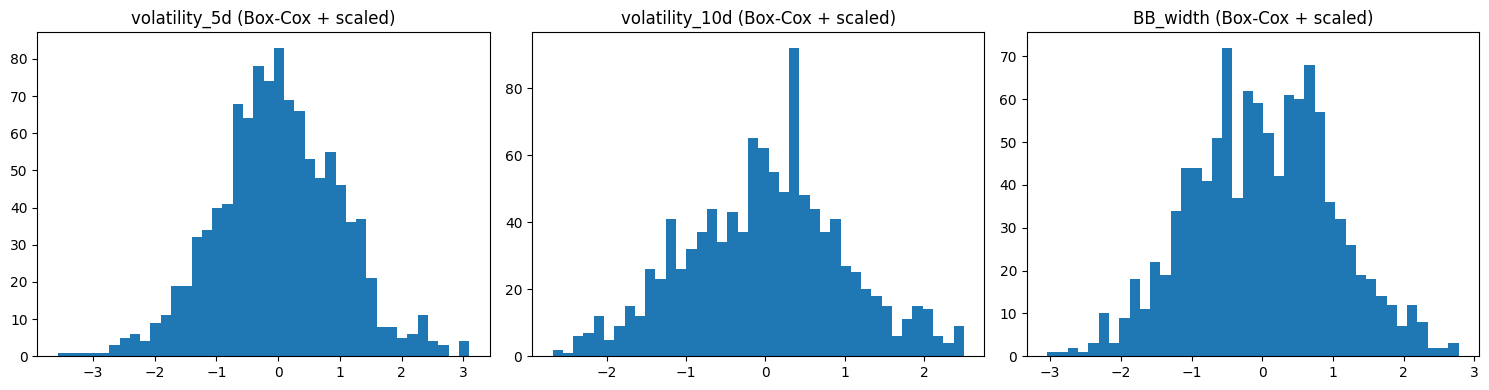

In [25]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
import pandas as pd

skewed_cols = ['volatility_5d', 'volatility_10d', 'BB_width']
other_cols = [c for c in X_train.columns if c not in skewed_cols]

# Step 1: Box-Cox transform + standardize the skewed columns
pt = PowerTransformer(method='box-cox', standardize=True)
X_train_bc = pt.fit_transform(X_train[skewed_cols])
X_test_bc = pt.transform(X_test[skewed_cols])

# Step 2: Standard scale the remaining (non-skewed) columns
scaler = StandardScaler()
X_train_other = scaler.fit_transform(X_train[other_cols])
X_test_other = scaler.transform(X_test[other_cols])

# Step 3: Combine both sets of transformed columns back into full dataframes
X_train_scaled = pd.DataFrame(
    X_train_bc, columns=skewed_cols, index=X_train.index
).join(
    pd.DataFrame(X_train_other, columns=other_cols, index=X_train.index)
)[X_train.columns]  # reorder to match original column order

X_test_scaled = pd.DataFrame(
    X_test_bc, columns=skewed_cols, index=X_test.index
).join(
    pd.DataFrame(X_test_other, columns=other_cols, index=X_test.index)
)[X_test.columns]

print(X_train_scaled.describe())

# Visual check
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(skewed_cols):
    axes[i].hist(X_train_scaled[col], bins=40)
    axes[i].set_title(f'{col} (Box-Cox + scaled)')
plt.tight_layout()
plt.show()

# logistic regression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

preds = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

print("\nFull Classification Report:")
print(classification_report(y_test, preds))

Accuracy: 0.49070631970260226
Precision: 0.4652777777777778
Recall: 0.5275590551181102
F1 Score: 0.4944649446494465

Confusion Matrix:
[[65 77]
 [60 67]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.46      0.49       142
           1       0.47      0.53      0.49       127

    accuracy                           0.49       269
   macro avg       0.49      0.49      0.49       269
weighted avg       0.49      0.49      0.49       269



In [27]:
import pandas as pd
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values(ascending=False)
print(coefs)

Price
RSI                0.326525
BB_low             0.179573
BB_width           0.165243
nifty_return_5d    0.127858
volatility_10d     0.019887
return_1d          0.009034
nifty_return_1d    0.002578
volatility_5d     -0.011104
MACD_diff         -0.091212
MACD_signal       -0.125656
MACD              -0.146302
BB_high           -0.209692
return_5d         -0.212331
dtype: float64


Positive coefficients (push toward predicting "up"):

RSI: 0.35 — highest positive weight. Makes intuitive sense — higher RSI often signals recent upward momentum, so the model leans "up" when RSI is high.
BB_low: 0.16 — when price is near/above the lower Bollinger Band, model leans slightly "up."
BB_width: 0.15 — wider bands (more volatility) slightly push toward "up" prediction.
volatility_10d, return_1d — small positive effect, close to negligible.
Negative coefficients (push toward predicting "down"):

BB_high: -0.19 — strongest negative weight. Makes sense — when price is near/above the upper Bollinger Band (statistically "overbought"/stretched high), the model leans toward predicting a pullback ("down"). This aligns with classic technical analysis intuition.
MACD: -0.16, MACD_signal: -0.13 — somewhat counterintuitive at first glance (usually rising MACD signals bullish momentum), but with correlated features like this, individual coefficients can behave unexpectedly — this is a known side effect of multicollinearity (remember MACD and MACD_signal were flagged as highly correlated in your profiling report).
return_5d: -0.14, MACD_diff: -0.09 — mild negative pull.
volatility_5d: -0.03 — negligible.

The important honest caveat to include in your writeup:
Since MACD/MACD_signal are highly correlated (and BB_high/BB_low/BB_width also share information), Logistic Regression coefficients become unstable and hard to interpret individually when inputs are correlated — the model can "split" credit/blame between correlated features in somewhat arbitrary ways. This is a well-known limitation of linear models in the presence of multicollinearity, and it's part of why  XGBoost feature importance (based on split usefulness, not linear coefficients) will likely be more reliable and worth trusting more.


"RSI and Bollinger Band position emerged as the strongest linear predictors of direction, consistent with momentum/mean-reversion intuition — though coefficient magnitudes for MACD-related features should be interpreted cautiously given multicollinearity flagged in the EDA."

# knn

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

preds_knn = knn_model.predict(X_test_scaled)


print("Accuracy:", accuracy_score(y_test, preds_knn))
print("Precision:", precision_score(y_test, preds_knn))
print("Recall:", recall_score(y_test, preds_knn))
print("F1 Score:", f1_score(y_test, preds_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds_knn))

print("\nFull Classification Report:")
print(classification_report(y_test, preds_knn))

Accuracy: 0.5353159851301115
Precision: 0.5070422535211268
Recall: 0.5669291338582677
F1 Score: 0.5353159851301115

Confusion Matrix:
[[72 70]
 [55 72]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.51      0.54       142
           1       0.51      0.57      0.54       127

    accuracy                           0.54       269
   macro avg       0.54      0.54      0.54       269
weighted avg       0.54      0.54      0.54       269



 Rule of thumb when comparing: prefer higher mean and lower std# 

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

for k in [5, 10, 15, 20, 25, 30]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    print(f"k={k}: mean CV accuracy = {scores.mean():.4f}, std = {scores.std():.4f}")

k=5: mean CV accuracy = 0.4958, std = 0.0301
k=10: mean CV accuracy = 0.5060, std = 0.0200
k=15: mean CV accuracy = 0.4902, std = 0.0318
k=20: mean CV accuracy = 0.4995, std = 0.0178
k=25: mean CV accuracy = 0.5023, std = 0.0270
k=30: mean CV accuracy = 0.5107, std = 0.0219


# descision tree

In [30]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import cross_val_score
# import numpy as np

# for depth in [2, 3, 4, 5, 6, 7, 8, 10, None]:
#     dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
#     scores = cross_val_score(dt, X_train, y_train, cv=5)
#     print(f"max_depth={depth}: mean CV accuracy = {scores.mean():.4f}, std = {scores.std():.4f}")

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


dt_model = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model.fit(X_train, y_train)

preds_dt = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, preds_dt))
print("Precision:", precision_score(y_test, preds_dt))
print("Recall:", recall_score(y_test, preds_dt))
print("F1 Score:", f1_score(y_test, preds_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds_dt))

print("\nFull Classification Report:")
print(classification_report(y_test, preds_dt))

Accuracy: 0.5353159851301115
Precision: 0.5087719298245614
Recall: 0.4566929133858268
F1 Score: 0.48132780082987553

Confusion Matrix:
[[86 56]
 [69 58]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.61      0.58       142
           1       0.51      0.46      0.48       127

    accuracy                           0.54       269
   macro avg       0.53      0.53      0.53       269
weighted avg       0.53      0.54      0.53       269



In [32]:

dt_final = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_final.fit(X_train, y_train) 


importances_dt = pd.Series(dt_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_dt)

Price
return_5d          0.148818
nifty_return_5d    0.130129
nifty_return_1d    0.129485
RSI                0.085643
MACD_diff          0.084382
BB_high            0.082673
volatility_10d     0.080224
BB_low             0.059890
volatility_5d      0.050723
MACD               0.046903
BB_width           0.041626
return_1d          0.034020
MACD_signal        0.025484
dtype: float64


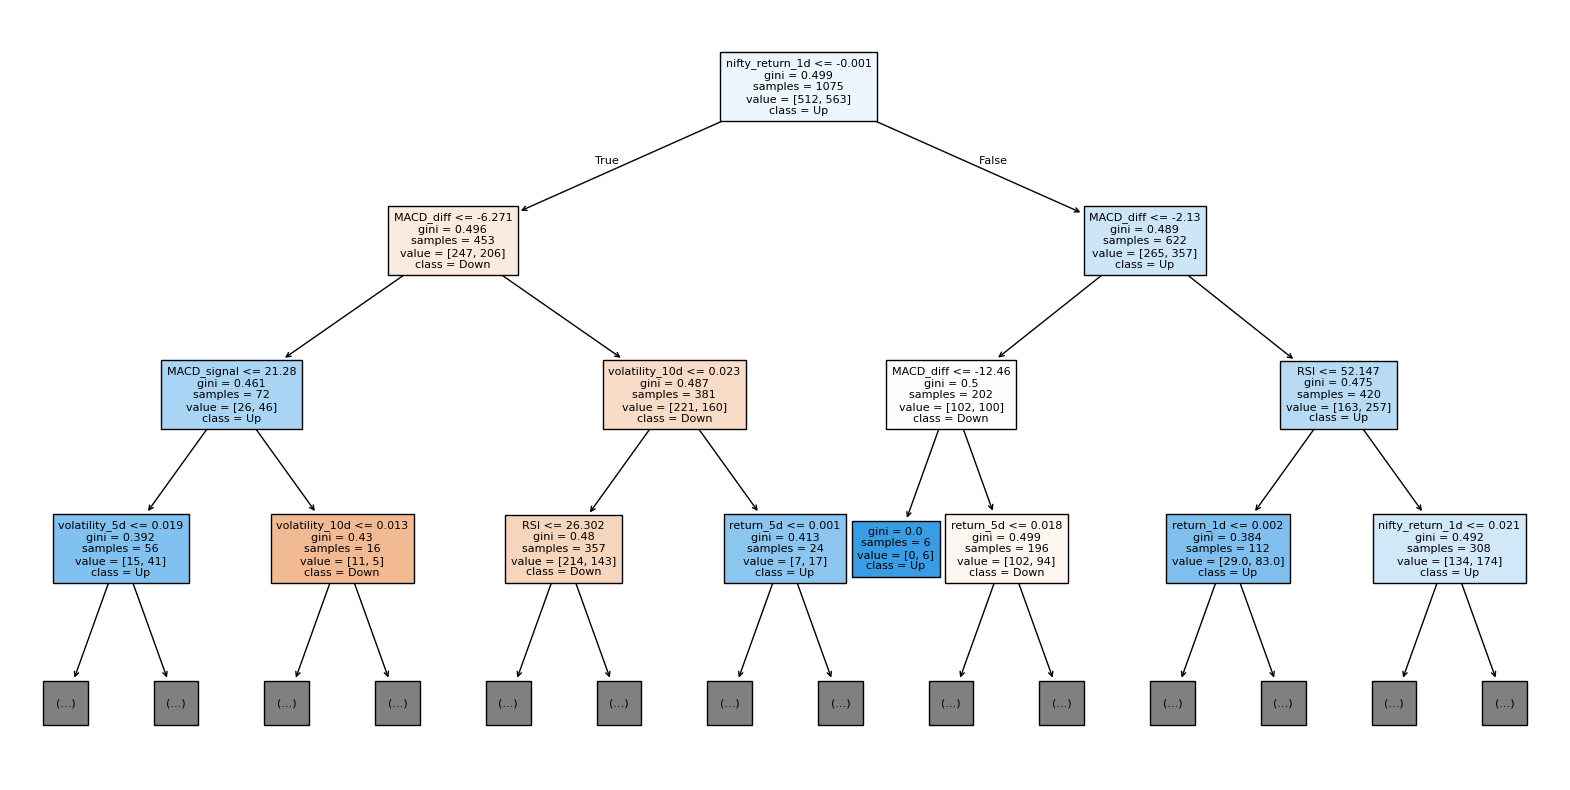

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=['Down','Up'], filled=True, max_depth=3, fontsize=8)
plt.show()

Is this a bug? No. This is a genuine, defensible finding: a single Decision Tree, even tuned, isn't a stable/fair classifier for this problem — it's biased toward one class. This is actually a great insight for your writeup, and it's exactly the kind of weakness that ensemble methods (Random Forest = many trees voting, which cancels out individual trees' biases) are designed to fix.

# gradient boosting

Why this helps: using less than 100% adds randomness between trees (similar spirit to how Random Forest uses random subsets), which reduces overfitting and often improves generalization — this specific technique even has a name, "Stochastic Gradient Boosting." It's a proven way to make boosting models more robust, at a small cost of slightly noisier individual trees (which the ensemble averages out anyway).
In boosting (Gradient Boosting, AdaBoost, XGBoost), each tree is meant to be a "weak learner" — deliberately simple, only slightly better than random guessing on its own. The power comes from combining hundreds of these weak trees sequentially, each correcting the previous ones' mistakes. If any single tree is too deep/complex, it starts fitting the data (and its noise) too well on its own — defeating the purpose of gradual, additive correction, and causing severe overfitting.

Contrast with Random Forest (bagging): there, each tree is trained independently and typically allowed to grow deep (max_depth=None or large values are common) — because Random Forest relies on averaging many independent, high-variance trees to cancel out noise. Boosting instead relies on many weak, low-variance trees improving together, sequentially — so depth needs to stay shallow by design

Boosting (GB, AdaBoost, XGBoost, LightGBM) → shallow trees (depth 2-5 typical), many estimators (100-500+)
Bagging (Random Forest, BaggingClassifier) → deeper trees (depth 10+, or unrestricted), fewer estimators (100-300 typical) needed relative to boosting

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


from xgboost import XGBClassifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print(grid_xgb.best_params_, grid_xgb.best_score_)

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0} 0.5404651162790698


suggests that more complexity (more trees, faster learning, deeper trees) didn't help and probably started overfitting,

In [35]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(scale_pos_weight)

0.9094138543516874


A value below 1 means pos > neg — your positive class (1, "up") is now more common than class 0 in this y_train, the opposite of before (when neg > pos gave you ~1.13).

# xg boost

## Final model — Nifty feature added (best result: 0.55 accuracy)
Baseline (technical indicators only) scored ~0.48. Adding Nifty 50 market 
features improved accuracy to 0.55 — see conclusion below for why.

In [36]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
best_xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    max_depth=4,
    colsample_bytree=0.7,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.7,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight
)

# param_grid = {
#     'max_depth': [2, 3, 4, 5],
#     'n_estimators': [50, 100, 150, 200],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1_macro',
#     n_jobs=-1,
#     verbose=1
# )
best_xgb.fit(X_train, y_train)
# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Best CV Score:", grid_search.best_score_)

# # Best XGBoost model
# best_xgb = grid_search.best_estimator_

# Predictions using best model
preds_xgb = best_xgb.predict(X_test)


print("Accuracy:", accuracy_score(y_test, preds_xgb))
print("Precision:", precision_score(y_test, preds_xgb))
print("Recall:", recall_score(y_test, preds_xgb))
print("F1 Score:", f1_score(y_test, preds_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds_xgb))

print("\nFull Report:\n", classification_report(y_test, preds_xgb))

importances_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importances:\n", importances_xgb)

Accuracy: 0.550185873605948
Precision: 0.5241935483870968
Recall: 0.5118110236220472
F1 Score: 0.5179282868525896

Confusion Matrix:
 [[83 59]
 [62 65]]

Full Report:
               precision    recall  f1-score   support

           0       0.57      0.58      0.58       142
           1       0.52      0.51      0.52       127

    accuracy                           0.55       269
   macro avg       0.55      0.55      0.55       269
weighted avg       0.55      0.55      0.55       269


Feature Importances:
 Price
nifty_return_1d    0.083684
return_5d          0.083136
MACD_diff          0.079789
volatility_10d     0.078926
MACD_signal        0.077639
MACD               0.077095
nifty_return_5d    0.076789
volatility_5d      0.075002
return_1d          0.074401
BB_high            0.074214
RSI                0.074059
BB_width           0.073997
BB_low             0.071269
dtype: float32


ne more interesting detail worth noting for your writeup: the feature importances are all pretty flat (0.071–0.084, tightly clustered) — no single feature dominates. That itself is informative: it suggests the signal is spread thin across many weak indicators combined, rather than one strong predictor. Worth a line in your report.

## Earlier experiments (kept for reference, not used in final model)

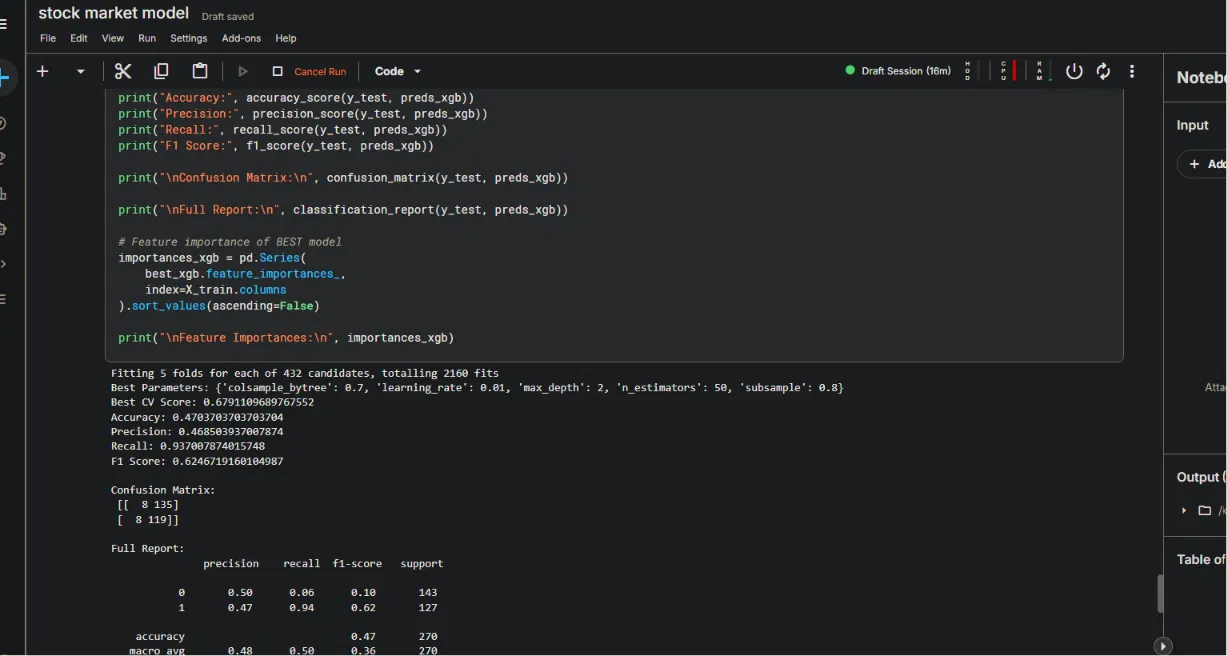 earlier

scale_pos_weight tells XGBoost: "when you get the positive class (1) wrong, penalize that mistake more heavily." This forces the model to actually try to catch class 1 instead of ignoring it to game the loss.

# "Baseline model (technical indicators only): ~48% accuracy, near-random. Adding broad market signal (Nifty 50 returns) improved accuracy to 55%, suggesting next-day stock direction is influenced more by overall market movement than by the stock's own technical indicators alone."

In [37]:
# print("Train accuracy:", accuracy_score(y_train, xgb_model.predict(X_train)))
# print("Test accuracy:", accuracy_score(y_test, preds_xgb))

Most likely cause: overfitting to training data, given your dataset size.
XGBoost and Random Forest are powerful, flexible models — with default settings (n_estimators=200, no depth limit specified for either), they can very easily memorize noise in your ~1100-row training set rather than learn generalizable patterns. Unlike your earlier Gradient Boosting (where you set max_depth=3 deliberately, keeping it shallow/weak), here:

# random forest

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd

best_rf= RandomForestClassifier(
    random_state=42,max_depth= None, max_features='sqrt', min_samples_leaf= 4, min_samples_split= 10, n_estimators= 200,class_weight='balanced'
)
best_rf.fit(X_train, y_train)
preds_rf = best_rf.predict(X_test)
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 5, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# }

# grid_search_rf = GridSearchCV(
#     estimator=rf_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1_macro',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search_rf.fit(X_train, y_train)

# print("Best Parameters:", grid_search_rf.best_params_)
# print("Best CV Score:", grid_search_rf.best_score_)

# # Best Random Forest model
# best_rf = grid_search_rf.best_estimator_

preds_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds_rf))
print("Precision:", precision_score(y_test, preds_rf))
print("Recall:", recall_score(y_test, preds_rf))
print("F1 Score:", f1_score(y_test, preds_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds_rf))

print("\nFull Report:\n", classification_report(y_test, preds_rf))


importances_rf = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importances:\n", importances_rf)

Accuracy: 0.516728624535316
Precision: 0.4881889763779528
Recall: 0.4881889763779528
F1 Score: 0.4881889763779528

Confusion Matrix:
 [[77 65]
 [65 62]]

Full Report:
               precision    recall  f1-score   support

           0       0.54      0.54      0.54       142
           1       0.49      0.49      0.49       127

    accuracy                           0.52       269
   macro avg       0.52      0.52      0.52       269
weighted avg       0.52      0.52      0.52       269


Feature Importances:
 Price
nifty_return_1d    0.105139
MACD_diff          0.084288
return_1d          0.081754
return_5d          0.081247
nifty_return_5d    0.076275
volatility_10d     0.075435
BB_width           0.074724
RSI                0.072926
BB_high            0.072324
volatility_5d      0.071915
MACD               0.069776
BB_low             0.069496
MACD_signal        0.064702
dtype: float64


## Conclusion

**Bug found:** Initial models collapsed to predicting "up" almost always — 
caused by GridSearchCV's default scoring optimizing only for the positive 
class. Fixed using scoring='f1_macro' and scale_pos_weight.

**Baseline (fixed, technical indicators only):** ~0.48 accuracy — near 
random, suggesting next-day direction is close to a random walk using only 
a stock's own technicals.

**Hypothesis:** broad market movement carries more predictive signal than 
individual stock indicators alone.

**Result:** adding Nifty 50 return features improved accuracy from 0.48 to 
0.55. nifty_return_1d ranked as the most important feature, confirming the 
hypothesis. Confusion matrix remained balanced across both classes.



## Future Improvements

- Use TimeSeriesSplit for cross-validation during hyperparameter tuning, 
  instead of a single chronological train/test split.
- Predict a longer horizon (5-day or 10-day direction) instead of next-day 
  — likely less noisy and closer to a real tradeable signal.
- Reframe the target as "big move" vs "small move/flat" instead of raw 
  up/down, to filter out noise-level price flips.
- Add sector-level or peer-stock features, not just broad market (Nifty), 
  since sector movement can carry more specific signal.
- Try LightGBM for comparison against XGBoost/RF/GB/KNN.
- Incorporate sentiment or news-based features, which technical indicators 
  alone can't capture.

## Scope

This project predicts short-term (next-day) price *direction*, not price 
*value* — it does not forecast exact prices or returns.

It is a research/learning exercise demonstrating an ML workflow (feature 
engineering, model comparison, debugging class imbalance, hypothesis-driven 
feature addition) — not a production trading signal. Real trading strategies 
would need transaction cost modeling, risk management, and much stronger 
predictive edge than ~55% accuracy provides.

Trained and evaluated on a single stock/time period; results may not 
generalize to other stocks or market regimes without retesting.